# Exoplanet Filter: TEPCat + TESS PDC-SAP Coverage

This notebook identifies which transiting exoplanets have both the Mandel-Agol required parameters in TEPCat and TESS PDC-SAP light curves available through MAST. The output is a curated planet list ready for MSD (Multi-Sector Detrending) analysis.

## Cell 1 — Setup

Import all required libraries and define global constants.

In [1]:
import pandas as pd
import requests
import lightkurve as lk
import time
import numpy as np
import matplotlib.pyplot as plt

SLEEP_BETWEEN_QUERIES = 0.5  # seconds between MAST lightkurve queries to avoid rate limiting

c:\Users\pnayg\Desktop\cvif-astro-p1\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Cell 2 — Download TEPCat

Fetch the TEPCat all-planets CSV directly from the Keele University server. TEPCat (Transiting Extrasolar Planet Catalogue) is maintained by John Southworth and contains homogeneously derived system parameters for well-studied transiting planets.

We save the raw download immediately so we have a local copy and do not need to re-fetch during development.

In [2]:
TEPCAT_URL = "https://www.astro.keele.ac.uk/jkt/tepcat/allplanets-csv.csv"

print("Fetching TEPCat catalogue...")
response = requests.get(TEPCAT_URL, timeout=60)
response.raise_for_status()

# Save raw download
with open("tepcat_raw.csv", "wb") as f:
    f.write(response.content)
print("Saved: tepcat_raw.csv")

# Load into dataframe — TEPCat uses a header row; skip comment lines starting with #
df_raw = pd.read_csv("tepcat_raw.csv", comment="#", skipinitialspace=True)

print(f"\nShape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print("\nAll column names:")
for col in df_raw.columns:
    print(f"  {col}")

print("\nFirst 5 rows:")
df_raw.head(5)

Fetching TEPCat catalogue...
Saved: tepcat_raw.csv

Shape: 1794 rows x 43 columns

All column names:
  System
  Teff
  err
  err.1
  [Fe/H]
  erru
  errd
  M_A
  errup
  errdn
  R_A
  errup.1
  errdn.1
  loggA
  errup.2
  errdn.2
  rho_A
  errup.3
  errdn.3
  Period
  e
  errup.4
  errdown
  a(AU)
  errup.5
  errdown.1
  M_b
  errup.6
  errdn.4
  R_b
  errup.7
  errdn.5
  g_b
  errup.8
  errdn.6
  rho_b
  errup.9
  errdn.7
  Teq
  err.2
  err.3
  Discovery_reference
  Recent_reference

First 5 rows:


,System,Teff,err,err.1,[Fe/H],erru,errd,M_A,errup,errdn,...,errup.8,errdn.6,rho_b,errup.9,errdn.7,Teq,err.2,err.3,Discovery_reference,Recent_reference
0,55_Cnc_e,5172,18,18,0.35,0.10,0.10,0.873,0.051,0.035,...,2.1,1.9,4.71,0.56,0.53,2349.0,188.0,193.0,2011ApJ...737L..18W,2019ApJ...883...79D
1,pi_Men_c,5998,62,62,0.09,0.04,0.04,1.091,0.031,0.031,...,1.9,9.5,2.10,0.40,0.4,1170.0,2.8,4.3,2018ApJ...868L..39H,2022AJ....163..223H
2,AD_3116,3184,29,29,0.14,0.10,0.10,0.280,0.030,0.030,...,-1.0,-1,-1.00,-1.00,-1,1669.0,244.0,258.0,2017ApJ...849...11G,2023MNRAS.519.5177C
3,AU_Mic_b,3540,120,110,0.01,0.06,0.06,0.635,0.040,0.070,...,-1.0,-1,0.37,0.12,0.12,556.0,8.0,9.0,2020Natur.582..497P,2025A+A...694A.137B
4,AU_Mic_c,3540,120,110,0.01,0.06,0.06,0.635,0.040,0.070,...,-1.0,-1,2.94,0.86,0.88,428.0,8.0,8.0,2021A+A...649A.177M,2025A+A...694A.137B


## Cell 3 — Identify the Right Columns

TEPCat's `allplanets-csv.csv` stores **physical parameters** (radii and semi-major axis in physical units), not the dimensionless transit observables directly. The Mandel-Agol parameters we need must be derived:

| Mandel-Agol param | Derivation | TEPCat columns used |
|-------------------|-----------|---------------------|
| Period (P) | direct | `Period` |
| Rp/Rs (k) | R_b / R_A | `R_b`, `R_A` (both in solar radii) |
| a/Rs | a(AU) / (R_A × R☉ in AU) | `a(AU)`, `R_A` |
| inclination (i) | **not in this file** | — |

Planet names use underscores (`55_Cnc_e`, `WASP-43_b`). Inclination is absent from this TEPCat table and must be sourced separately if needed for full Mandel-Agol fitting.

In [3]:
print("Full column list with dtypes:")
print(df_raw.dtypes.to_string())

# Show columns relevant to what we need
relevant = ["System", "Period", "R_A", "R_b", "a(AU)"]
available = [c for c in relevant if c in df_raw.columns]
print(f"\nKey columns available: {available}")
print("\nSample of 10 rows showing key columns:")
df_raw[available].head(10)

Full column list with dtypes:
System                     str
Teff                     int64
err                      int64
err.1                    int64
[Fe/H]                 float64
erru                   float64
errd                   float64
M_A                    float64
errup                  float64
errdn                  float64
R_A                    float64
errup.1                float64
errdn.1                float64
loggA                  float64
errup.2                float64
errdn.2                    str
rho_A                  float64
errup.3                float64
errdn.3                float64
Period                 float64
e                      float64
errup.4                float64
errdown                float64
a(AU)                  float64
errup.5                float64
errdown.1                  str
M_b                    float64
errup.6                float64
errdn.4                float64
R_b                    float64
errup.7                float64
errdn.5  

,System,Period,R_A,R_b,a(AU)
0,55_Cnc_e,0.737,0.954,0.1692,0.01544
1,pi_Men_c,6.268,1.190,0.1914,0.06876
2,AD_3116,1.983,0.290,0.9500,-1.00000
3,AU_Mic_b,8.463,0.862,0.4120,0.06940
4,AU_Mic_c,18.859,0.862,0.2460,0.11690
5,CoRoT-01,1.509,1.131,1.5510,0.02536
6,CoRoT-02,1.743,0.901,1.4600,0.02835
7,CoRoT-03,4.257,1.660,1.0800,0.05783
8,CoRoT-04,9.202,1.148,1.1600,0.09120
9,CoRoT-05,4.038,1.115,1.2560,0.04950


## Cell 4 — Derive Parameters and Filter TEPCat

Since TEPCat stores physical radii, we derive the dimensionless transit parameters:

- **Rp/Rs** = `R_b / R_A` (planet radius / star radius, both already in solar radii)
- **a/Rs** = `a(AU) / (R_A × 0.00465047)` — converts AU to solar radii then divides

We filter to keep only rows where Period, Rp/Rs, and a/Rs are all present and non-zero. Inclination is not available in this file and is noted as missing.

In [4]:
R_SUN_AU = 0.00465047  # solar radius in AU

df_work = df_raw.copy()

# Ensure physical columns are numeric
for col in ["Period", "R_A", "R_b", "a(AU)"]:
    df_work[col] = pd.to_numeric(df_work[col], errors="coerce")

# Derive Mandel-Agol transit parameters
df_work["Rp_Rs"] = df_work["R_b"] / df_work["R_A"]
df_work["a_Rs"]  = df_work["a(AU)"] / (df_work["R_A"] * R_SUN_AU)

COL_NAME   = "System"
COL_PERIOD = "Period"
COL_RPRS   = "Rp_Rs"
COL_ARS    = "a_Rs"

# Filter: Period, Rp/Rs, a/Rs must be non-null and non-zero
mask = (
    df_work[COL_PERIOD].notna() & (df_work[COL_PERIOD] > 0) &
    df_work[COL_RPRS].notna()   & (df_work[COL_RPRS]   > 0) &
    df_work[COL_ARS].notna()    & (df_work[COL_ARS]    > 0)
)

df_filtered = df_work[mask].reset_index(drop=True)

print(f"Total planets in TEPCat  : {len(df_raw)}")
print(f"After parameter filter   : {len(df_filtered)}")
print(f"Removed (incomplete data): {len(df_raw) - len(df_filtered)}")
print(f"\nNote: inclination (i) is not present in this TEPCat file.")
print(f"      It must be sourced separately for full Mandel-Agol modeling.")

df_filtered.to_csv("tepcat_qualified.csv", index=False)
print("\nSaved: tepcat_qualified.csv")
df_filtered[[COL_NAME, COL_PERIOD, COL_RPRS, COL_ARS]].head(10)

Total planets in TEPCat  : 1794
After parameter filter   : 1566
Removed (incomplete data): 228

Note: inclination (i) is not present in this TEPCat file.
      It must be sourced separately for full Mandel-Agol modeling.

Saved: tepcat_qualified.csv


,System,Period,Rp_Rs,a_Rs
0,55_Cnc_e,0.737,0.177358,3.480183
1,pi_Men_c,6.268,0.160840,12.424876
2,AU_Mic_b,8.463,0.477958,17.312323
3,AU_Mic_c,18.859,0.285383,29.161536
4,CoRoT-01,1.509,1.371353,4.821585
5,CoRoT-02,1.743,1.620422,6.765991
6,CoRoT-03,4.257,0.650602,7.491146
7,CoRoT-04,9.202,1.010453,17.082684
8,CoRoT-05,4.038,1.126457,9.546265
9,CoRoT-06,8.887,1.136146,17.627266


In [8]:
def extract_host_star(system_name):
    """Strip trailing underscore + planet letter from TEPCat System name."""
    name = str(system_name).strip()
    parts = name.split("_")
    if len(parts) >= 2 and len(parts[-1]) == 1 and parts[-1].isalpha():
        parts = parts[:-1]
    return " ".join(parts)


def query_tess_coverage(host_star):
    """Query MAST for TESS 2-min light curves. Returns (has_pdcsap, n_sectors, sector_list_str)."""
    try:
        results = lk.search_lightcurve(host_star, mission="TESS", exptime=120)
        if results is None or len(results) == 0:
            return False, 0, ""

        table = results.table

        # 'sequence_number' is the TESS sector number in lightkurve's MAST results table
        sector_col = next(
            (c for c in table.colnames if c.lower() in ("sequence_number", "sector")),
            None
        )
        if sector_col:
            sectors = sorted(set(int(s) for s in table[sector_col] if s is not None))
        else:
            print(f"  WARNING: sector column not found. Columns: {table.colnames}")
            sectors = []

        return True, len(sectors), str(sectors)

    except Exception as e:
        return False, 0, f"ERROR: {e}"


# --- Smart resume: patch sector data only for planets already known to have TESS data ---
import os

if os.path.exists("tess_coverage_raw.csv"):
    df_existing = pd.read_csv("tess_coverage_raw.csv")
    needs_patch = df_existing["has_pdcsap"] == True
    patch_indices = df_existing[needs_patch].index.tolist()
    print(f"Found existing tess_coverage_raw.csv with {len(df_existing)} rows.")
    print(f"Re-querying {len(patch_indices)} planets with has_pdcsap=True to fix sector numbers...")
    print(f"(Skipping {len(df_existing) - len(patch_indices)} planets with no TESS data)\n")

    for count, idx in enumerate(patch_indices):
        planet = df_existing.loc[idx, COL_NAME]
        host = extract_host_star(planet)
        _, n_sectors, sector_list = query_tess_coverage(host)
        df_existing.loc[idx, "n_sectors"]   = n_sectors
        df_existing.loc[idx, "sector_list"] = sector_list
        time.sleep(SLEEP_BETWEEN_QUERIES)

        if (count + 1) % 50 == 0 or (count + 1) == len(patch_indices):
            print(f"  [{count+1}/{len(patch_indices)}] patched")

    df_coverage = df_existing
    df_coverage.to_csv("tess_coverage_raw.csv", index=False)
    print("\nSaved patched: tess_coverage_raw.csv")

else:
    # Full run from scratch
    planet_names  = df_filtered[COL_NAME].tolist()
    coverage_rows = []
    print(f"Querying TESS coverage for {len(planet_names)} planets...")
    print(f"(sleeping {SLEEP_BETWEEN_QUERIES}s between queries)\n")

    for i, planet in enumerate(planet_names):
        host = extract_host_star(planet)
        has_pdcsap, n_sectors, sector_list = query_tess_coverage(host)
        coverage_rows.append({
            COL_NAME:      planet,
            "host_star":   host,
            "has_pdcsap":  has_pdcsap,
            "n_sectors":   n_sectors,
            "sector_list": sector_list,
        })
        time.sleep(SLEEP_BETWEEN_QUERIES)

        if (i + 1) % 50 == 0 or (i + 1) == len(planet_names):
            found_so_far = sum(r["has_pdcsap"] for r in coverage_rows)
            print(f"  [{i+1}/{len(planet_names)}] checked — {found_so_far} with TESS PDC-SAP so far")

    df_coverage = pd.DataFrame(coverage_rows)
    df_coverage.to_csv("tess_coverage_raw.csv", index=False)
    print("\nSaved: tess_coverage_raw.csv")

df_coverage.head()

Found existing tess_coverage_raw.csv with 1566 rows.
Re-querying 1477 planets with has_pdcsap=True to fix sector numbers...
(Skipping 89 planets with no TESS data)

  [50/1477] patched
  [100/1477] patched
  [150/1477] patched
  [200/1477] patched
  [250/1477] patched
  [300/1477] patched
  [350/1477] patched
  [400/1477] patched
  [450/1477] patched
  [500/1477] patched
  [550/1477] patched
  [600/1477] patched
  [650/1477] patched
  [700/1477] patched
  [750/1477] patched
  [800/1477] patched
  [850/1477] patched
  [900/1477] patched
  [950/1477] patched
  [1000/1477] patched
  [1050/1477] patched
  [1100/1477] patched
  [1150/1477] patched
  [1200/1477] patched
  [1250/1477] patched
  [1300/1477] patched
  [1350/1477] patched
  [1400/1477] patched
  [1450/1477] patched
  [1477/1477] patched

Saved patched: tess_coverage_raw.csv


,System,host_star,has_pdcsap,n_sectors,sector_list
0,55_Cnc_e,55 Cnc,True,4,"[21, 44, 46, 72]"
1,pi_Men_c,pi Men,True,24,"[1, 4, 8, 11, 12, 13, 27, 28, 31, 34, 38, 39, ..."
2,AU_Mic_b,AU Mic,True,3,"[1, 27, 95]"
3,AU_Mic_c,AU Mic,True,3,"[1, 27, 95]"
4,CoRoT-01,CoRoT-01,True,3,"[6, 33, 87]"


## Cell 5 — TESS Coverage Check

For each planet that passed the parameter filter, we query the MAST archive via `lightkurve.search_lightcurve()` to check whether TESS PDC-SAP light curves exist at the 2-minute (120 s) cadence.

**Host star extraction rule:** Remove the trailing single-letter planet designation and the space before it. Examples:
- `"WASP-43 b"` → `"WASP-43"`
- `"HAT-P-32 b"` → `"HAT-P-32"`
- `"Kepler-10 b"` → `"Kepler-10"`

We sleep `SLEEP_BETWEEN_QUERIES` seconds between each call to stay within MAST rate limits. Progress is printed every 50 planets.

In [5]:
def extract_host_star(system_name):
    """Strip trailing underscore + planet letter from TEPCat System name.
    
    TEPCat uses underscores as delimiters: '55_Cnc_e' → '55 Cnc', 'WASP-43_b' → 'WASP-43'.
    We remove the last segment if it is a single letter, then convert remaining underscores to spaces.
    """
    name = str(system_name).strip()
    parts = name.split("_")
    if len(parts) >= 2 and len(parts[-1]) == 1 and parts[-1].isalpha():
        parts = parts[:-1]
    return " ".join(parts)


def query_tess_coverage(host_star):
    """Query MAST for TESS 2-min light curves. Returns (has_pdcsap, n_sectors, sector_list_str).
    
    exptime=120 already restricts to 2-minute cadence TESS products, which are PDC-SAP.
    No additional string filtering needed — it was incorrectly discarding all results.
    """
    try:
        results = lk.search_lightcurve(host_star, mission="TESS", exptime=120)
        if results is None or len(results) == 0:
            return False, 0, ""

        table = results.table

        # Extract sector numbers
        sector_col = next((c for c in table.colnames if "sector" in c.lower()), None)
        if sector_col:
            sectors = sorted(set(int(s) for s in table[sector_col] if s is not None))
        else:
            sectors = list(range(len(table)))

        return True, len(sectors), str(sectors)

    except Exception as e:
        return False, 0, f"ERROR: {e}"


# Run the coverage check
planet_names  = df_filtered[COL_NAME].tolist()
coverage_rows = []

print(f"Querying TESS coverage for {len(planet_names)} planets...")
print(f"(sleeping {SLEEP_BETWEEN_QUERIES}s between queries)\n")

for i, planet in enumerate(planet_names):
    host = extract_host_star(planet)
    has_pdcsap, n_sectors, sector_list = query_tess_coverage(host)
    coverage_rows.append({
        COL_NAME:      planet,
        "host_star":   host,
        "has_pdcsap":  has_pdcsap,
        "n_sectors":   n_sectors,
        "sector_list": sector_list,
    })
    time.sleep(SLEEP_BETWEEN_QUERIES)

    if (i + 1) % 50 == 0 or (i + 1) == len(planet_names):
        found_so_far = sum(r["has_pdcsap"] for r in coverage_rows)
        print(f"  [{i+1}/{len(planet_names)}] checked — {found_so_far} with TESS PDC-SAP so far")

df_coverage = pd.DataFrame(coverage_rows)
df_coverage.to_csv("tess_coverage_raw.csv", index=False)
print("\nSaved: tess_coverage_raw.csv")
df_coverage.head()

Querying TESS coverage for 1566 planets...
(sleeping 0.5s between queries)



No data found for target "CoRoT-27".
No data found for target "CoRoT-35".
No data found for target "CoRoT-36".


  [50/1566] checked — 44 with TESS PDC-SAP so far


No data found for target "EPIC 247422570".
No data found for target "GJ 1214".


  [100/1566] checked — 92 with TESS PDC-SAP so far
  [150/1566] checked — 142 with TESS PDC-SAP so far
  [200/1566] checked — 191 with TESS PDC-SAP so far
  [250/1566] checked — 241 with TESS PDC-SAP so far


...

No data found for target "WASP-103".


  [1500/1566] checked — 1412 with TESS PDC-SAP so far


No data found for target "WASP-157".


  [1550/1566] checked — 1461 with TESS PDC-SAP so far
  [1566/1566] checked — 1477 with TESS PDC-SAP so far

Saved: tess_coverage_raw.csv


,System,host_star,has_pdcsap,n_sectors,sector_list
0,55_Cnc_e,55 Cnc,True,4,"[0, 1, 2, 3]"
1,pi_Men_c,pi Men,True,26,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,AU_Mic_b,AU Mic,True,4,"[0, 1, 2, 3]"
3,AU_Mic_c,AU Mic,True,4,"[0, 1, 2, 3]"
4,CoRoT-01,CoRoT-01,True,3,"[0, 1, 2]"


## Cell 6 — Merge and Summarize

Merge the TEPCat filtered parameters with the TESS coverage results on planet name. We then report a three-level funnel:

1. All planets in TEPCat
2. Planets that passed the Mandel-Agol parameter filter
3. Planets that also have at least one TESS PDC-SAP sector

The final merged dataframe — sorted by number of TESS sectors — is saved as the input list for the MSD modeling pipeline.

In [6]:
# Merge on planet name
df_merged = df_filtered.merge(df_coverage, on=COL_NAME, how="left")

# Summary counts
n_total    = len(df_raw)
n_filtered = len(df_filtered)
n_tess     = df_merged["has_pdcsap"].sum()

print("=" * 50)
print("PLANET FILTER SUMMARY")
print("=" * 50)
print(f"Total planets in TEPCat          : {n_total}")
print(f"Passed Mandel-Agol param filter  : {n_filtered}")
print(f"With TESS PDC-SAP light curves   : {int(n_tess)}")
print(f"Pass rate (param filter)         : {n_filtered/n_total*100:.1f}%")
print(f"Pass rate (TESS coverage)        : {int(n_tess)/n_filtered*100:.1f}%")
print("=" * 50)

# Final ready list: must pass both filters
df_ready = (
    df_merged[df_merged["has_pdcsap"] == True]
    .sort_values("n_sectors", ascending=False)
    .reset_index(drop=True)
)

df_ready.to_csv("planets_ready_for_modeling.csv", index=False)
print(f"\nSaved: planets_ready_for_modeling.csv ({len(df_ready)} planets)")

# Display key columns only (COL_INC not available in this TEPCat file)
display_cols = [COL_NAME, "host_star", COL_PERIOD, COL_RPRS, COL_ARS, "n_sectors", "sector_list"]
display_cols = [c for c in display_cols if c in df_ready.columns]
df_ready[display_cols]

PLANET FILTER SUMMARY
Total planets in TEPCat          : 1794
Passed Mandel-Agol param filter  : 1566
With TESS PDC-SAP light curves   : 1477
Pass rate (param filter)         : 87.3%
Pass rate (TESS coverage)        : 94.3%

Saved: planets_ready_for_modeling.csv (1477 planets)


,System,host_star,Period,Rp_Rs,a_Rs,n_sectors,sector_list
0,TOI-1452,TOI-1452,11.062,0.542545,47.698014,83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,GJ_0238,GJ 0238,1.745,0.117061,10.582128,50,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,HD_028109b,HD 028109b,22.891,0.168421,20.477085,50,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,HD_028109d,HD 028109d,84.290,0.194386,62.019764,50,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,HD_028109c,HD 028109c,55.997,0.258246,46.477098,50,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
...,...,...,...,...,...,...,...
1472,CoRoT-09,CoRoT-09,95.273,1.110417,90.067061,1,[0]
1473,CoRoT-06,CoRoT-06,8.887,1.136146,17.627266,1,[0]
1474,TOI-954,TOI-954,3.685,0.450317,5.639476,1,[0]
1475,TOI-969,TOI-969,1.824,0.367660,8.447458,1,[0]


## Cell 7 — Quick Stats: Top 20 Planets by TESS Sector Count

A bar chart of the 20 planets with the richest TESS datasets. More sectors mean more transits, better phase coverage, and more robust MSD detrending. This plot is a quick visual guide for prioritizing which systems to model first.

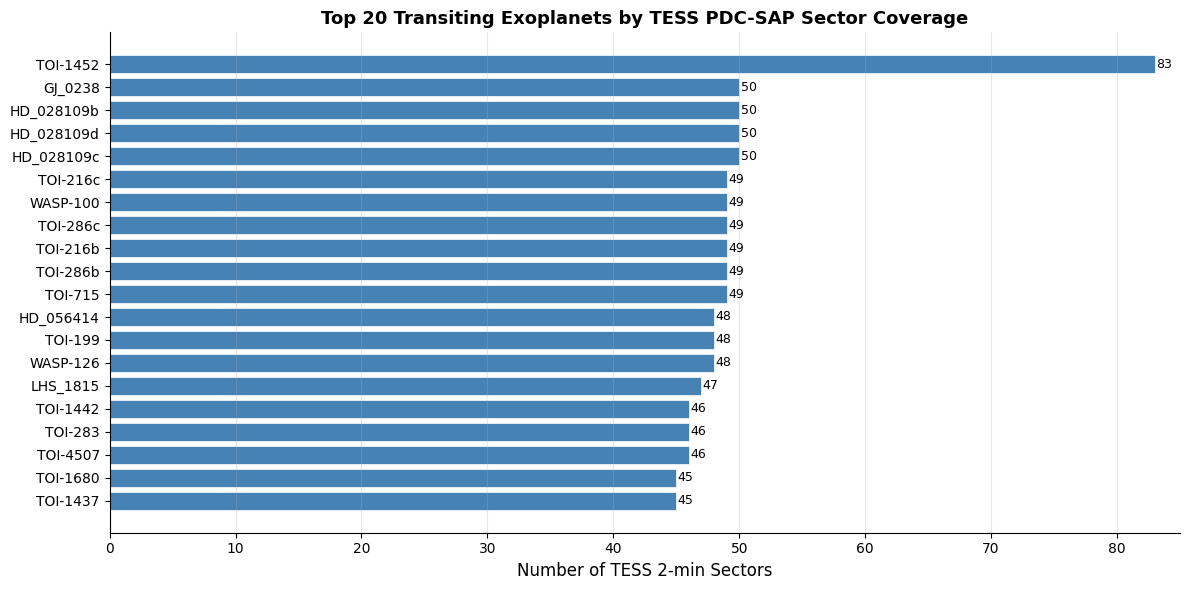

Saved: top20_tess_sectors.png


In [9]:
top20 = df_ready[[COL_NAME, "n_sectors"]].head(20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top20[COL_NAME][::-1],   # reverse so highest is at top
    top20["n_sectors"][::-1],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)

# Annotate bar values
for bar, val in zip(bars, top20["n_sectors"][::-1]):
    ax.text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
        str(int(val)), va="center", ha="left", fontsize=9
    )

ax.set_xlabel("Number of TESS 2-min Sectors", fontsize=12)
ax.set_title("Top 20 Transiting Exoplanets by TESS PDC-SAP Sector Coverage", fontsize=13, fontweight="bold")
ax.set_xlim(0, top20["n_sectors"].max() + 2)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("top20_tess_sectors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top20_tess_sectors.png")

## Cell 8 — Select 5 Hot Jupiters + 5 Mini-Neptunes

Filter the 1,477 qualified planets into two groups for the MMWN analysis.

**Unit note:** In TEPCat, `R_b` is in **Jupiter radii** and `R_A` (stellar radius) is in **solar radii**. We classify on `R_b` directly:

| Type | R_b (R_Jup) | Period (days) | Host Teff (K) |
|------|------------|---------------|---------------|
| Hot Jupiter (HJ) | > 0.70 | < 10 | 4800–7500 |
| Mini-Neptune (MN) | 0.18–0.36 | < 10 | 4800–7500 |

We then find the single TESS sector that covers the most planets across both groups and select the top 5 per group in that sector.

In [ ]:
import ast

# Load the saved CSV (which has patched sector_list with real sector numbers)
df_ready2 = pd.read_csv("../planets_ready_for_modeling.csv")

# Pull in R_b and Teff from the raw TEPCat data
tepcat = pd.read_csv("tepcat_raw.csv", comment="#", skipinitialspace=True)
tepcat = tepcat[["System", "R_b", "Teff"]].copy()
tepcat["R_b"]  = pd.to_numeric(tepcat["R_b"],  errors="coerce")
tepcat["Teff"] = pd.to_numeric(tepcat["Teff"], errors="coerce")

df_all = df_ready2.merge(tepcat, on="System", how="left")

# Parse sector_list strings → actual Python lists
def parse_sectors(s):
    try:
        return ast.literal_eval(str(s))
    except Exception:
        return []

df_all["sectors_parsed"] = df_all["sector_list"].apply(parse_sectors)

# ── Type filters ──────────────────────────────────────────────────────────────
FG_LO, FG_HI = 4800, 7500   # F/G host star Teff range

mask_fg = df_all["Teff"].between(FG_LO, FG_HI)
mask_p  = df_all["Period"] < 10.0
mask_rb_valid = df_all["R_b"] > 0

mask_hj = mask_fg & mask_p & mask_rb_valid & (df_all["R_b"] > 0.70)
mask_mn = mask_fg & mask_p & mask_rb_valid & (df_all["R_b"].between(0.18, 0.36))

df_hj = df_all[mask_hj].copy()
df_mn = df_all[mask_mn].copy()

print(f"Hot Jupiters (R_b > 0.70 Rjup, P < 10d, F/G host): {len(df_hj)}")
print(f"Mini-Neptunes (0.18–0.36 Rjup, P < 10d, F/G host): {len(df_mn)}")
print()
print("HJ sample:")
print(df_hj[["System", "R_b", "Period", "Teff", "n_sectors"]].head(10).to_string(index=False))
print()
print("MN sample:")
print(df_mn[["System", "R_b", "Period", "Teff", "n_sectors"]].head(10).to_string(index=False))

In [ ]:
from collections import Counter

# Count how many HJ+MN candidates appear in each sector
sector_counts = Counter()
for sectors in df_hj["sectors_parsed"]:
    sector_counts.update(sectors)
for sectors in df_mn["sectors_parsed"]:
    sector_counts.update(sectors)

print("Top 15 sectors by number of HJ+MN candidates covered:")
for sec, cnt in sector_counts.most_common(15):
    print(f"  Sector {sec:>3}: {cnt} planets")

BEST_SECTOR = sector_counts.most_common(1)[0][0]
print(f"\nBest sector: {BEST_SECTOR}")

# Filter to planets in the best sector
def in_sector(sectors_list, sec):
    return sec in sectors_list

df_hj["in_best"] = df_hj["sectors_parsed"].apply(lambda s: in_sector(s, BEST_SECTOR))
df_mn["in_best"] = df_mn["sectors_parsed"].apply(lambda s: in_sector(s, BEST_SECTOR))

hj_in = df_hj[df_hj["in_best"]].sort_values("n_sectors", ascending=False)
mn_in = df_mn[df_mn["in_best"]].sort_values("n_sectors", ascending=False)

print(f"\nHot Jupiters in Sector {BEST_SECTOR}: {len(hj_in)}")
print(f"Mini-Neptunes in Sector {BEST_SECTOR}: {len(mn_in)}")

In [ ]:
# ── Final selection: top 5 per group ─────────────────────────────────────────
# Prefer planets with more TESS sectors (more data = more reliable ephemerides)
# Secondary sort: larger R_b for HJ, middle of range for MN

top_hj = hj_in.nlargest(5, "n_sectors")[["System", "host_star", "R_b", "Period", "Teff", "n_sectors"]]
top_mn = mn_in.nlargest(5, "n_sectors")[["System", "host_star", "R_b", "Period", "Teff", "n_sectors"]]

top_hj = top_hj.reset_index(drop=True)
top_mn = top_mn.reset_index(drop=True)
top_hj.index += 1
top_mn.index += 1

print("=" * 65)
print(f"FINAL SELECTION — Sector {BEST_SECTOR}")
print("=" * 65)
print(f"\n5 Hot Jupiters (R_b > 0.70 R_Jup, Period < 10d):")
print(top_hj.to_string())
print(f"\n5 Mini-Neptunes (0.18–0.36 R_Jup, Period < 10d):")
print(top_mn.to_string())

# Save final selection
top_hj["type"] = "Hot Jupiter"
top_mn["type"] = "Mini-Neptune"
df_final = pd.concat([top_hj, top_mn], ignore_index=True)
df_final["sector"] = BEST_SECTOR
df_final.to_csv("../selected_10_planets.csv", index=False)
print(f"\nSaved: selected_10_planets.csv")